# 04_베이스라인 — PyCaret 시간CV 비교 + 통일 평가(macro-F1·PR-AUC)

**목적:** 최종 피처 104개(03 산출)로 베이스라인을 확정한다. ① PyCaret compare(시간 CV = 확장 윈도우 4폴드)로 지형 파악 ② class_weight 적용 SOTA 3종(LGBM/XGB/CatBoost) + 기준선 2종(다수결 더미, 로지스틱)을 **동일 CV·동일 지표**로 통일 평가 ③ Holdout-Valid 전 지표 보고 ④ pkl 저장.

**평가지표(사용자 확정 2026-07-16):** 주지표 **macro-F1**, 공동 주지표 **PR-AUC(macro, One-vs-Rest 평균)**. 추가 보조지표: 급증·급감 클래스별 AP·recall·precision, balanced accuracy, MCC, Cohen's κ, log loss. **accuracy는 단독 보고 금지**(유지 79%라 전부 '유지'로 찍어도 ~0.79) — 참고 열로만 표기.

**입력:** `data/processed/모델셋_최종_L3.parquet`, `models/피처목록.json` / **출력:** `models/04_*.pkl`, `outputs/figures/04_*.png`, `outputs/tables/04_*.csv`

**분할:** Train 202304~202403(3,384) 내부 확장 윈도우 4폴드 CV → Holdout-Valid 202406~202411(1,692). Test는 06에서 1회만 사용(§7).

In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common
from common import IM, LABEL_COLOR, SEED, set_korean_font, save_fig
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 220)

data = pd.read_parquet('../data/processed/모델셋_최종_L3.parquet')
FEATS = json.load(open('../models/피처목록.json', encoding='utf-8'))['final_features']
CLS = ['급감', '급증', '유지']

train = data[data['구간'] == 'Train'].reset_index(drop=True)
valid = data[data['구간'] == 'Valid'].reset_index(drop=True)
Xtr, ytr = train[FEATS], train['라벨']
Xva, yva = valid[FEATS], valid['라벨']
print(f'Train {Xtr.shape} / Valid {Xva.shape} / 피처 {len(FEATS)}개')
print('Train 라벨 분포:', ytr.value_counts(normalize=True).round(3).to_dict())

# 확장 윈도우 4폴드 (기준월 시간순, §7)
FOLD_DEF = [((202304, 202307), (202308, 202309)), ((202304, 202309), (202310, 202311)),
            ((202304, 202311), (202312, 202401)), ((202304, 202401), (202402, 202403))]

class ExpandingMonthCV:
    def __init__(self, months, folds):
        self.m = np.asarray(months); self.folds = folds
    def split(self, X=None, y=None, groups=None):
        for (a, b), (c, d) in self.folds:
            yield (np.where((self.m >= a) & (self.m <= b))[0],
                   np.where((self.m >= c) & (self.m <= d))[0])
    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)

cv = ExpandingMonthCV(train['기준월'].values, FOLD_DEF)
for i, (tr_i, va_i) in enumerate(cv.split()):
    print(f'  fold{i+1}: train {len(tr_i):,} (~{FOLD_DEF[i][0][1]}) → val {len(va_i):,} ({FOLD_DEF[i][1][0]}~{FOLD_DEF[i][1][1]})')

Train (3384, 104) / Valid (1692, 104) / 피처 104개
Train 라벨 분포: {'유지': 0.763, '급증': 0.124, '급감': 0.113}
  fold1: train 1,128 (~202307) → val 564 (202308~202309)
  fold2: train 1,692 (~202309) → val 564 (202310~202311)
  fold3: train 2,256 (~202311) → val 564 (202312~202401)
  fold4: train 2,820 (~202401) → val 564 (202402~202403)


## 1. 통일 평가 함수 — macro-F1 · PR-AUC(macro) · 클래스별 · 보조지표

In [2]:
from sklearn.metrics import (f1_score, average_precision_score, balanced_accuracy_score,
                             matthews_corrcoef, cohen_kappa_score, log_loss, accuracy_score,
                             recall_score, precision_score)
from sklearn.preprocessing import label_binarize

def eval_all(y_true, y_pred, proba):
    yb = label_binarize(y_true, classes=CLS)
    ap = {c: average_precision_score(yb[:, i], proba[:, i]) for i, c in enumerate(CLS)}
    return {
        'F1(macro)': f1_score(y_true, y_pred, average='macro'),
        'PR-AUC(macro)': np.mean(list(ap.values())),
        'AP_급증': ap['급증'], 'AP_급감': ap['급감'],
        'recall_급증': recall_score(y_true, y_pred, labels=['급증'], average='macro', zero_division=0),
        'recall_급감': recall_score(y_true, y_pred, labels=['급감'], average='macro', zero_division=0),
        'precision_급증': precision_score(y_true, y_pred, labels=['급증'], average='macro', zero_division=0),
        'precision_급감': precision_score(y_true, y_pred, labels=['급감'], average='macro', zero_division=0),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
        'LogLoss': log_loss(y_true, proba, labels=CLS),
        '(참고)Acc': accuracy_score(y_true, y_pred),
    }
print('지표 세트 정의 완료 — 주지표 F1(macro)·PR-AUC(macro), 클래스별 AP/recall/precision, BalancedAcc·MCC·Kappa·LogLoss')

지표 세트 정의 완료 — 주지표 F1(macro)·PR-AUC(macro), 클래스별 AP/recall/precision, BalancedAcc·MCC·Kappa·LogLoss


## 2. PyCaret compare — 시간 CV 전달, 최소 전처리(우리 파이프라인 신뢰)

In [3]:
from pycaret.classification import setup, compare_models, pull

s = setup(data=train[FEATS + ['라벨']], target='라벨', test_data=valid[FEATS + ['라벨']],
          preprocess=False, session_id=SEED, fold_strategy=cv, data_split_shuffle=False,
          html=False, verbose=False, index=False)
set_korean_font()   # §10: PyCaret setup이 matplotlib 설정을 초기화하므로 반드시 재호출

best = compare_models(include=['dummy', 'lr', 'lightgbm', 'xgboost', 'catboost'],
                      sort='MCC', errors='ignore', verbose=False)
cmp_tab = pull()
display(cmp_tab)
cmp_tab.to_csv('../outputs/tables/04_pycaret_compare.csv', encoding='utf-8-sig')
print('주의 1: 이 표는 지형 파악용 — F1 열은 가중(weighted) F1이라 다수 클래스(유지 76%)에 지배된다. 공식 지표(macro-F1·PR-AUC)는 §3.')
print('주의 2: preprocess=False라 NaN 미허용 모델(lr)과 문자 라벨 미지원 모델(xgboost sklearn API)은 자동 탈락 — §3에서 임퓨트·인코딩 파이프라인으로 별도 평가.')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.7957,0.8181,0.7957,0.7566,0.7571,0.3189,0.3567,4.6375
lightgbm,Light Gradient Boosting Machine,0.7926,0.8138,0.7926,0.7576,0.7546,0.3142,0.3483,0.2475
dummy,Dummy Classifier,0.7655,0.5000,0.7655,0.5863,0.6639,0.0000,0.0000,0.9075


주의 1: 이 표는 지형 파악용 — F1 열은 가중(weighted) F1이라 다수 클래스(유지 76%)에 지배된다. 공식 지표(macro-F1·PR-AUC)는 §3.
주의 2: preprocess=False라 NaN 미허용 모델(lr)과 문자 라벨 미지원 모델(xgboost sklearn API)은 자동 탈락 — §3에서 임퓨트·인코딩 파이프라인으로 별도 평가.


**해석 —** PyCaret 지형 파악의 요점: ① **더미가 Accuracy 0.7655**를 기록 — "accuracy 단독 보고 금지"(§10)의 실증이다(전부 '유지'로 찍어도 77%). ② 트리 부스팅(lightgbm·catboost)이 AUC 0.81대로 로지스틱·더미와 뚜렷이 구분 — 비선형 신호가 실재. ③ lr(NaN 미허용)·xgboost(sklearn API의 문자 라벨 미지원)는 preprocess=False 환경에서 자동 탈락 — 우리 전처리를 신뢰하는 설계(§10)의 부작용이므로, 공식 비교는 §3에서 동일 조건(임퓨트·인코딩·class weight)으로 수행한다.

## 3. 본 비교 — class_weight 적용 SOTA 3종 + 기준선 2종, 동일 시간 CV + Holdout-Valid 전 지표

§10: 클래스 불균형 대응은 기본 class_weight(SMOTE는 OFF, 05에서 재검토). PyCaret compare는 기본 하이퍼파라미터(불균형 미대응)라, 본 표가 공식 베이스라인이다.

In [4]:
import lightgbm as lgb
import xgboost as xgb_lib
from catboost import CatBoostClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

y_code = {c: i for i, c in enumerate(CLS)}

def make_models():
    return {
        '더미(다수결)': Pipeline([('imp', SimpleImputer(strategy='median')),
                                  ('m', DummyClassifier(strategy='most_frequent'))]),
        '로지스틱(균형)': Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()),
                                    ('m', LogisticRegression(max_iter=3000, class_weight='balanced',
                                                             random_state=SEED))]),
        'LightGBM(균형)': lgb.LGBMClassifier(class_weight='balanced', random_state=SEED, verbosity=-1),
        'XGBoost(가중)': xgb_lib.XGBClassifier(tree_method='hist', random_state=SEED,
                                                eval_metric='mlogloss'),
        'CatBoost(균형)': CatBoostClassifier(auto_class_weights='Balanced', random_seed=SEED,
                                              verbose=0, allow_writing_files=False),
    }

def fit_predict(name, model, X1, y1, X2):
    if 'XGBoost' in name:
        yc = y1.map(y_code)
        model.fit(X1, yc, sample_weight=compute_sample_weight('balanced', yc))
        proba = model.predict_proba(X2)
        pred = pd.Series(np.argmax(proba, axis=1)).map({v: k for k, v in y_code.items()}).values
    else:
        model.fit(X1, y1)
        proba = model.predict_proba(X2)
        cols = list(model.classes_) if not isinstance(model, Pipeline) else list(model.named_steps['m'].classes_)
        proba = proba[:, [cols.index(c) for c in CLS]]
        pred = model.predict(X2)
    return pred, proba

cv_rows, va_rows = [], []
for name in make_models():
    f1s, praucs = [], []
    for tr_i, va_i in cv.split():
        m = make_models()[name]
        pred, proba = fit_predict(name, m, Xtr.iloc[tr_i], ytr.iloc[tr_i], Xtr.iloc[va_i])
        e = eval_all(ytr.iloc[va_i], pred, proba)
        f1s.append(e['F1(macro)']); praucs.append(e['PR-AUC(macro)'])
    m = make_models()[name]
    pred, proba = fit_predict(name, m, Xtr, ytr, Xva)
    ev = eval_all(yva, pred, proba)
    cv_rows.append({'모델': name, 'CV F1(macro)': f'{np.mean(f1s):.4f}±{np.std(f1s):.3f}',
                    'CV PR-AUC': f'{np.mean(praucs):.4f}±{np.std(praucs):.3f}'})
    va_rows.append({'모델': name, **{k: round(v, 4) for k, v in ev.items()}})
    globals()[f'_fitted_{name}'] = m
    globals()[f'_proba_{name}'] = proba

cv_tab = pd.DataFrame(cv_rows).set_index('모델')
va_tab = pd.DataFrame(va_rows).set_index('모델')
display(cv_tab)
display(va_tab[['F1(macro)', 'PR-AUC(macro)', 'AP_급증', 'AP_급감', 'recall_급증', 'recall_급감',
                'precision_급증', 'precision_급감', 'BalancedAcc', 'MCC', 'Kappa', 'LogLoss', '(참고)Acc']])
va_tab.to_csv('../outputs/tables/04_valid_전지표.csv', encoding='utf-8-sig')
cv_tab.to_csv('../outputs/tables/04_시간CV_요약.csv', encoding='utf-8-sig')
prev = yva.value_counts(normalize=True)
print(f'PR-AUC 우연 수준(=클래스 유병률): 급증 {prev["급증"]:.3f} / 급감 {prev["급감"]:.3f} / 유지 {prev["유지"]:.3f}')

,CV F1(macro),CV PR-AUC
모델,,
더미(다수결),0.2890±0.004,0.3333±0.000
로지스틱(균형),0.4196±0.068,0.4975±0.011
LightGBM(균형),0.5573±0.027,0.6068±0.014
XGBoost(가중),0.5488±0.030,0.6055±0.016
CatBoost(균형),0.5698±0.023,0.6194±0.026


,F1(macro),PR-AUC(macro),AP_급증,AP_급감,recall_급증,recall_급감,precision_급증,precision_급감,BalancedAcc,MCC,Kappa,LogLoss,(참고)Acc
모델,,,,,,,,,,,,,
더미(다수결),0.2997,0.3333,0.0768,0.1064,0.0000,0.0000,0.0000,0.0000,0.3333,0.0000,0.0000,6.6037,0.8168
로지스틱(균형),0.4460,0.4838,0.1243,0.4234,0.4846,0.4833,0.1270,0.3480,0.5281,0.2275,0.1926,0.9573,0.5922
LightGBM(균형),0.4960,0.5269,0.1379,0.5249,0.2308,0.4278,0.1293,0.5385,0.4947,0.2414,0.2388,0.6535,0.7376
XGBoost(가중),0.4953,0.5206,0.1425,0.5042,0.2154,0.3778,0.1466,0.5484,0.4852,0.2520,0.2510,0.7109,0.7612
CatBoost(균형),0.5038,0.5343,0.1515,0.5340,0.2462,0.4611,0.1391,0.5155,0.5098,0.2616,0.2583,0.6253,0.7394


PR-AUC 우연 수준(=클래스 유병률): 급증 0.077 / 급감 0.106 / 유지 0.817


**해석 —** ① **공식 베이스라인 = CatBoost(균형): 시간 CV macro-F1 0.5698±0.023 → Holdout-Valid 0.5038, PR-AUC(macro) 0.5343.** LGBM(0.4960/0.5269)·XGB(0.4953/0.5206)가 근소 열세로 뒤따른다. ② 기준선 격차가 모델 가치를 증명한다: 더미 0.2997(참고 Acc는 0.8168이나 급증·급감 recall 0 — accuracy의 허구성), 로지스틱 0.4460 → 트리 대비 macro-F1 +0.058의 비선형 이득. ③ **CV(0.570) vs Valid(0.504) 격차 −0.066**: 02에서 실측한 라벨 시간 드리프트(Valid 급증 7.7% vs Train 12.4%)와 정합 — 시점 일반화의 실제 난이도이며 05 튜닝에서도 이 격차를 기대치로 잡는다. ④ PR-AUC 분해: **급감 AP 0.534 = 유병률 0.106의 ×5.0**(강한 신호) vs **급증 AP 0.152 = 유병률 0.077의 ×2.0**(최난 클래스 재확인 — 명세서 §6-7과 동일 구조). 급증은 recall 0.246·precision 0.139로 05의 표적(임계 조정·클래스 가중 탐색·SMOTE 재검토)이다.

## 4. 최고 모델 상세 — confusion matrix(원본+행정규화) + 클래스별 PR 곡선(Valid)

Valid F1(macro) 최고: CatBoost(균형) = 0.5038 / PR-AUC 0.5343
              precision    recall  f1-score   support

          급감      0.516     0.461     0.487       180
          급증      0.139     0.246     0.178       130
          유지      0.873     0.822     0.847      1382

    accuracy                          0.739      1692
   macro avg      0.509     0.510     0.504      1692
weighted avg      0.779     0.739     0.757      1692



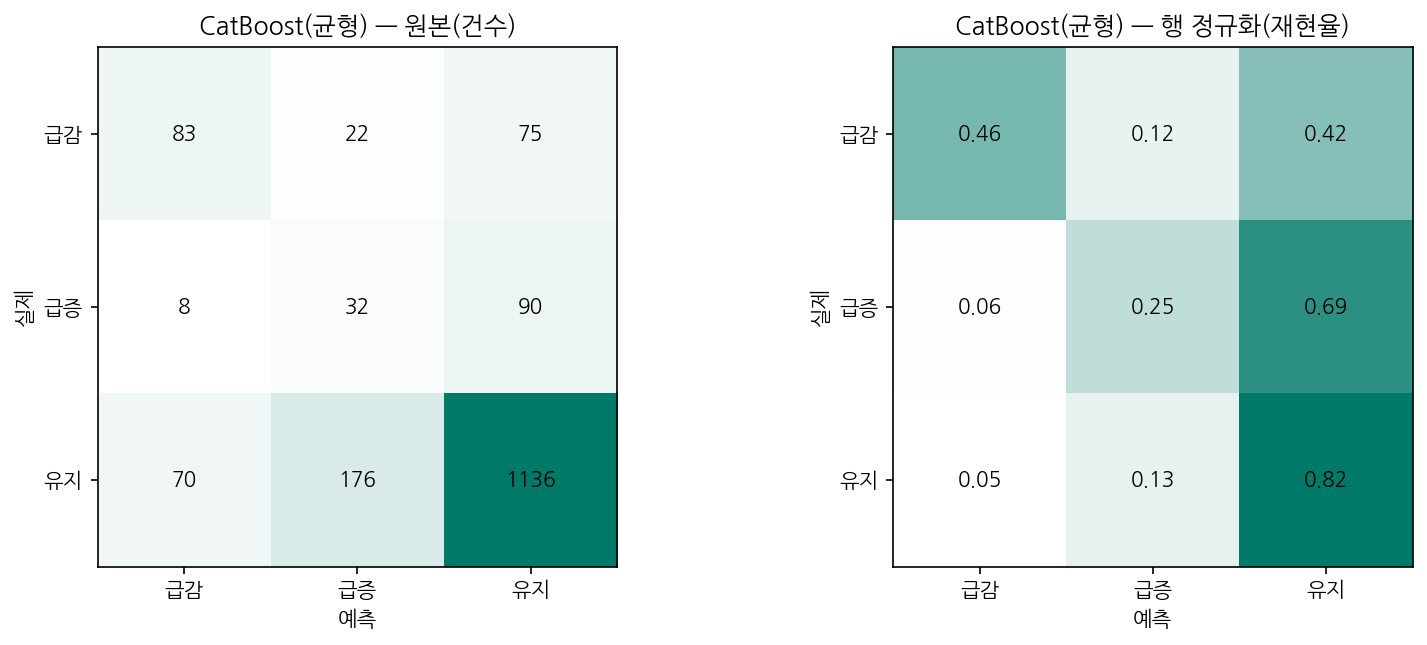

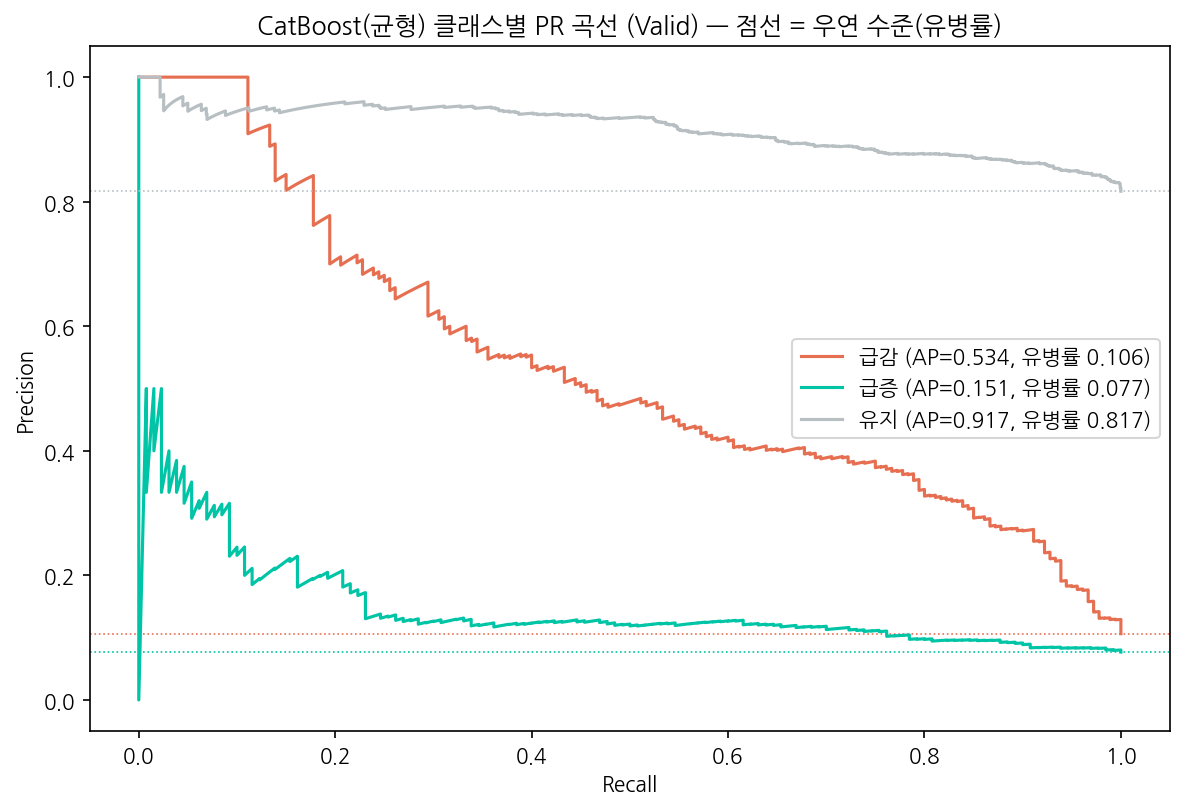

In [5]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, classification_report
import matplotlib as mpl

best_name = va_tab['F1(macro)'].idxmax()
best_model = globals()[f'_fitted_{best_name}']
best_proba = globals()[f'_proba_{best_name}']
if 'XGBoost' in best_name:
    best_pred = pd.Series(np.argmax(best_proba, axis=1)).map({v: k for k, v in y_code.items()}).values
else:
    best_pred = best_model.predict(Xva)
print(f'Valid F1(macro) 최고: {best_name} = {va_tab.loc[best_name, "F1(macro)"]:.4f} / PR-AUC {va_tab.loc[best_name, "PR-AUC(macro)"]:.4f}')
print(classification_report(yva, best_pred, digits=3))

cm = confusion_matrix(yva, best_pred, labels=CLS)
cmn = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, M, ttl, fmt in [(axes[0], cm, '원본(건수)', 'd'), (axes[1], cmn, '행 정규화(재현율)', '.2f')]:
    ax.imshow(M, cmap=mpl.colors.LinearSegmentedColormap.from_list('c', ['white', IM['딥민트']]))
    ax.set_xticks(range(3)); ax.set_xticklabels(CLS); ax.set_yticks(range(3)); ax.set_yticklabels(CLS)
    ax.set_xlabel('예측'); ax.set_ylabel('실제'); ax.set_title(f'{best_name} — {ttl}')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, format(M[i, j], fmt), ha='center', va='center', fontsize=10)
plt.tight_layout(); save_fig(fig, '04_01_confusion_valid.png'); plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))
yb = label_binarize(yva, classes=CLS)
for i, c in enumerate(CLS):
    pr, rc, _ = precision_recall_curve(yb[:, i], best_proba[:, i])
    ap = average_precision_score(yb[:, i], best_proba[:, i])
    ax.plot(rc, pr, color=LABEL_COLOR[c], label=f'{c} (AP={ap:.3f}, 유병률 {yb[:, i].mean():.3f})')
    ax.axhline(yb[:, i].mean(), color=LABEL_COLOR[c], ls=':', lw=0.8)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'{best_name} 클래스별 PR 곡선 (Valid) — 점선 = 우연 수준(유병률)')
ax.legend()
plt.tight_layout(); save_fig(fig, '04_02_PR곡선_valid.png'); plt.show()

**해석 —** confusion matrix에서 오류의 구조가 보인다: 급감 recall 0.461·급증 recall 0.246이며, **누락의 대부분은 '유지'로의 흡수**다(급증·급감 간 상호 오분류는 소수) — 즉 모델은 "변화가 있다/없다"의 경계에서 보수적으로 유지에 붙는다. PR 곡선에서 급감은 전 recall 구간에서 유병률(점선) 대비 크게 위에 있으나, 급증 곡선은 낮게 깔린다 — 평균회귀 신호(03 §5)가 급감(고점 되돌림)에는 강하지만 급증(저기저 반등)에는 노이즈가 크다는 명세서 §6-7 구조의 재현. **05 개선 방향:** Optuna 튜닝(목적 = 시간 CV macro-F1) + 급증 표적 처방(결정 임계 조정, class weight 그리드, SMOTE 재검토 — §15 상의 항목).

## 5. 모델 저장 (앙상블 재조합용, §10)

In [6]:
import joblib
for name, fname in [('LightGBM(균형)', '04_lgbm'), ('XGBoost(가중)', '04_xgb'),
                    ('CatBoost(균형)', '04_catboost'), ('로지스틱(균형)', '04_logistic')]:
    joblib.dump(globals()[f'_fitted_{name}'], f'../models/{fname}.pkl')
json.dump({'classes': CLS, 'y_code': y_code, 'feats': FEATS,
           'fold_def': FOLD_DEF, 'valid_best': best_name},
          open('../models/04_베이스라인_메타.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)
print('저장: models/04_lgbm.pkl, 04_xgb.pkl, 04_catboost.pkl, 04_logistic.pkl, 04_베이스라인_메타.json')

저장: models/04_lgbm.pkl, 04_xgb.pkl, 04_catboost.pkl, 04_logistic.pkl, 04_베이스라인_메타.json


**04 결론 —** 베이스라인 확정: **CatBoost(균형) Valid macro-F1 0.5038 / PR-AUC(macro) 0.5343** (기준선 더미 0.2997·로지스틱 0.4460 대비 명확한 이득, 3종 부스팅 격차는 ±0.008로 근소). 4개 모델 pkl + 메타(피처 목록·폴드 정의·클래스 순서) 저장 완료 — 06 앙상블에서 로드해 재조합한다.

**05_고도화 계획:** ① Optuna 3종(각 n_trials=50 또는 30분, TPESampler(seed=42), 목적함수 = 시간 CV 평균 macro-F1) ② 급증 표적: 결정 임계·class weight 그리드, SMOTE 재검토(§15 상의) ③ DL 후보 비교표(LSTM/GRU vs 1D-CNN vs MLP — 사용 가능 샘플 감소량 수치 포함) 제시 후 사용자 승인 → 구현(EarlyStopping, 학습곡선, 과적합 수치).